In [5]:
import pandas as pd


df_heart_failure = pd.read_csv('/heart_failure_clinical_records_dataset.csv')
display(df_heart_failure.head())

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0.0,20.0,1.0,265000.00,1.9,130,1.0,0.0,4,1.0
1,55.0,0,7861,0.0,38.0,0.0,263358.03,1.1,136,1.0,0.0,6,1.0
2,65.0,0,146,0.0,20.0,0.0,162000.00,1.3,129,1.0,1.0,7,1.0
3,50.0,1,111,0.0,20.0,0.0,210000.00,1.9,137,1.0,0.0,7,1.0
4,65.0,1,160,1.0,20.0,0.0,327000.00,2.7,116,0.0,0.0,8,1.0


## Dataset Summary

In [6]:
# Report the number of rows and columns
print(f"Number of rows: {df_heart_failure.shape[0]}")
print(f"Number of columns: {df_heart_failure.shape[1]}\n")

# Report data types and non-null values
print("Data types and non-null counts:")
df_heart_failure.info()

# Report missing values
print("\nMissing values per column:")
display(df_heart_failure.isnull().sum())

Number of rows: 299
Number of columns: 13

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  298 non-null    float64
 4   ejection_fraction         298 non-null    float64
 5   high_blood_pressure       298 non-null    float64
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       298 non-null    float64
 10  smoking                   296 non-null    float64
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               298 non-null    flo

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,1
ejection_fraction,1
high_blood_pressure,1
platelets,0
serum_creatinine,0
serum_sodium,0
sex,1


## Visualize Missing Values

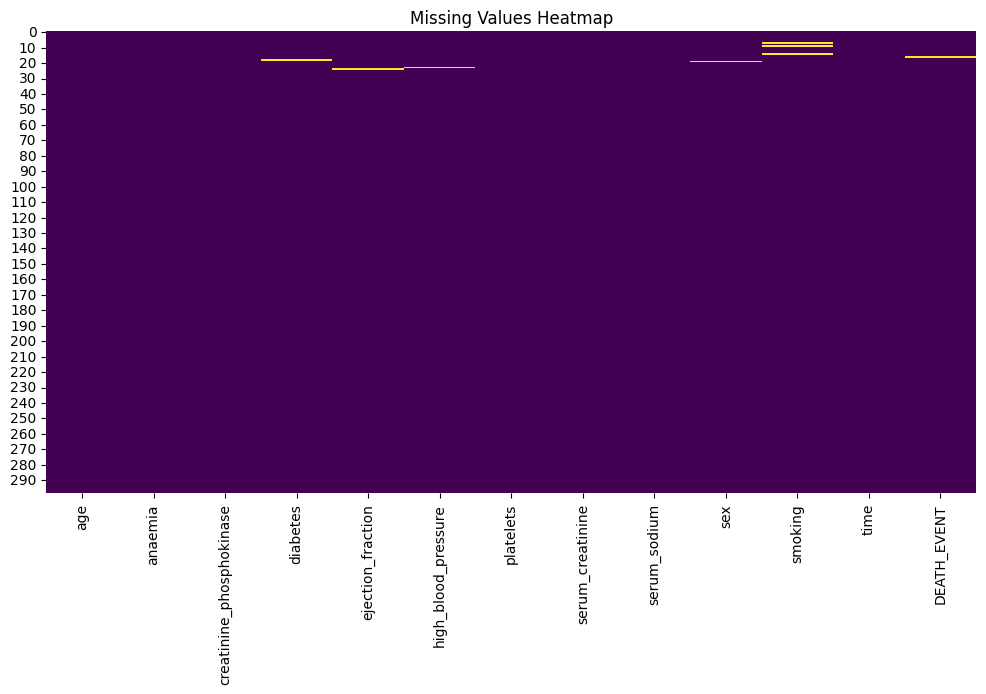

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap to visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df_heart_failure.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

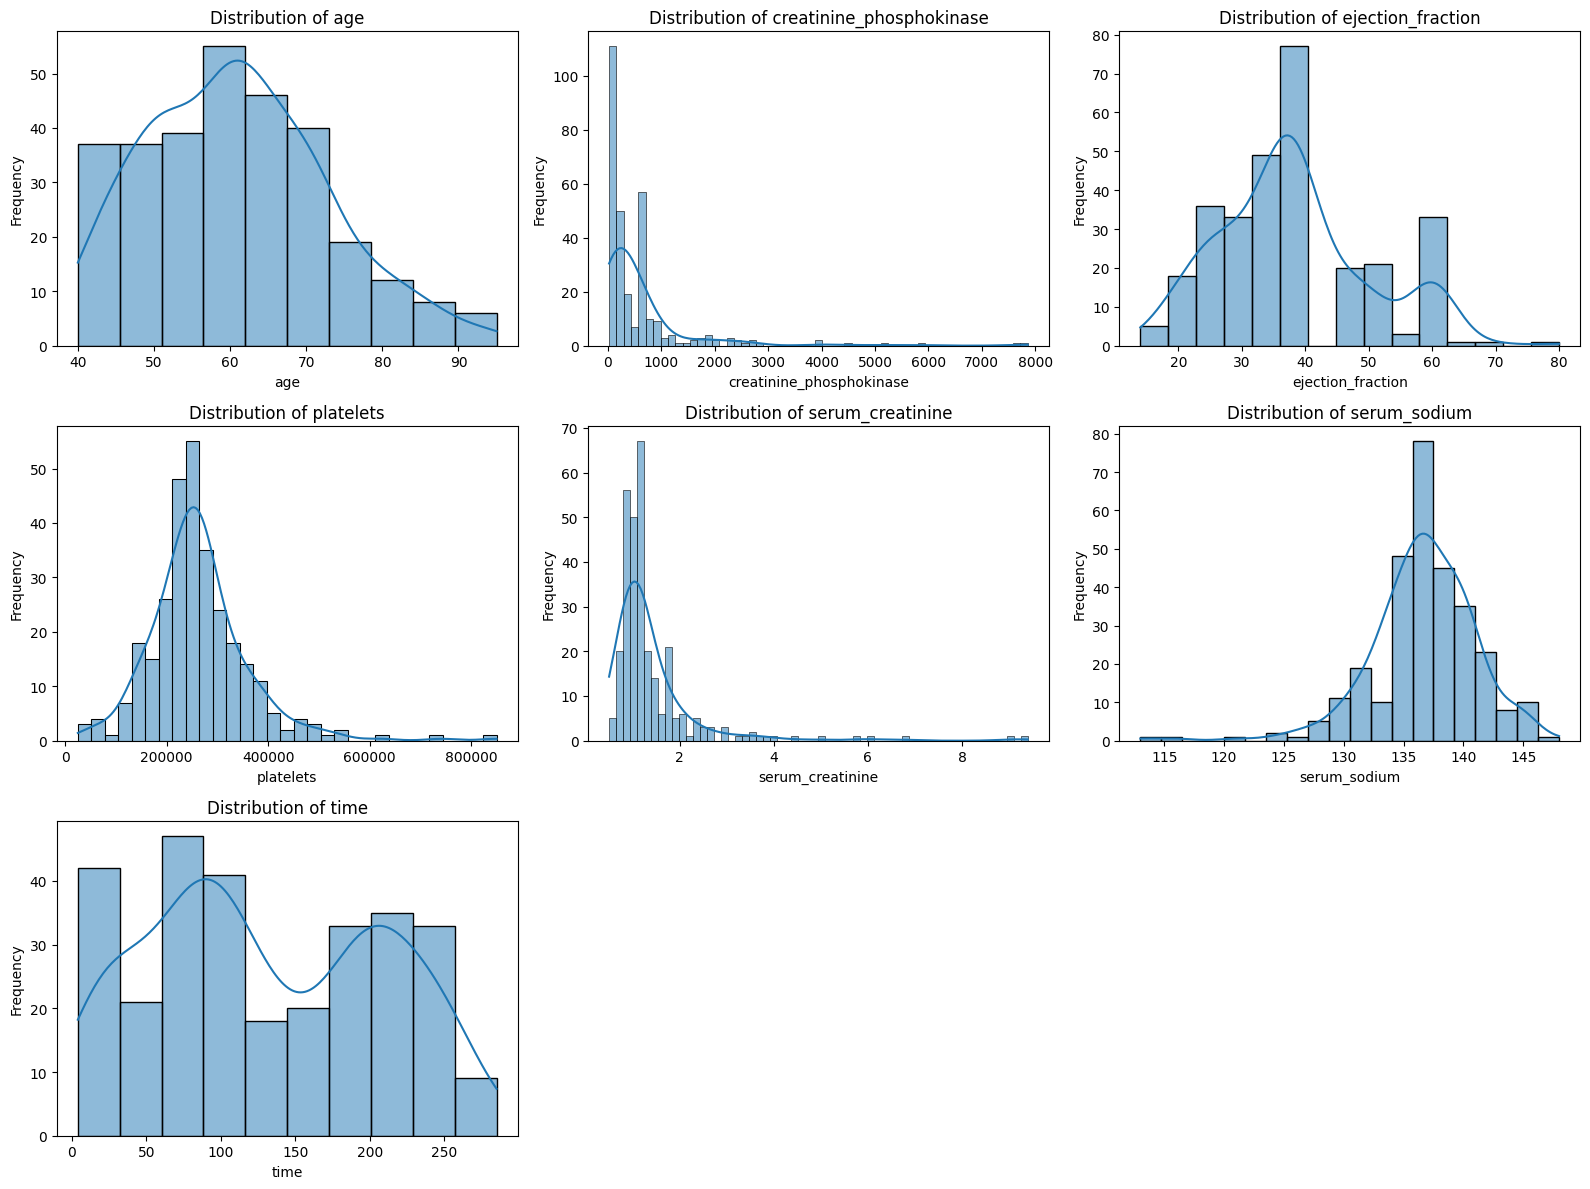

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

plt.figure(figsize=(16, 12))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i) # Adjust grid size as needed
    sns.histplot(df_heart_failure[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Optionally, you can also generate boxplots for outlier detection
# plt.figure(figsize=(16, 12))
# for i, feature in enumerate(numerical_features, 1):
#     plt.subplot(3, 3, i)
#     sns.boxplot(y=df_heart_failure[feature])
#     plt.title(f'Boxplot of {feature}')
#     plt.ylabel(feature)
# plt.tight_layout()
# plt.show()

In [9]:
# Impute Missing Values

# Identify features with missing values (from previous df.isnull().sum() output)
missing_numerical_features = ['ejection_fraction']
missing_categorical_features = ['diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']

# Impute numerical features with median
for feature in missing_numerical_features:
    median_value = df_heart_failure[feature].median()
    df_heart_failure[feature].fillna(median_value, inplace=True)
    print(f"Imputed '{feature}' with median value: {median_value}")

# Impute categorical features with mode
for feature in missing_categorical_features:
    mode_value = df_heart_failure[feature].mode()[0]
    df_heart_failure[feature].fillna(mode_value, inplace=True)
    print(f"Imputed '{feature}' with mode value: {mode_value}")

# Verify that there are no more missing values
print("\nMissing values after imputation:")
display(df_heart_failure.isnull().sum())

Imputed 'ejection_fraction' with median value: 38.0
Imputed 'diabetes' with mode value: 0.0
Imputed 'high_blood_pressure' with mode value: 0.0
Imputed 'sex' with mode value: 1.0
Imputed 'smoking' with mode value: 0.0
Imputed 'DEATH_EVENT' with mode value: 0.0

Missing values after imputation:


/tmp/ipykernel_1930/4158941138.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_heart_failure[feature].fillna(median_value, inplace=True)
/tmp/ipykernel_1930/4158941138.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [11]:
print(f"Shape of DataFrame before outlier removal: {df_heart_failure.shape}")

numerical_features_for_outliers = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

df_heart_failure_cleaned = df_heart_failure.copy()

for feature in numerical_features_for_outliers:
    Q1 = df_heart_failure_cleaned[feature].quantile(0.25)
    Q3 = df_heart_failure_cleaned[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    initial_rows = df_heart_failure_cleaned.shape[0]
    df_heart_failure_cleaned = df_heart_failure_cleaned[
        (df_heart_failure_cleaned[feature] >= lower_bound) &
        (df_heart_failure_cleaned[feature] <= upper_bound)
    ]
    rows_removed = initial_rows - df_heart_failure_cleaned.shape[0]
    if rows_removed > 0:
        print(f"Removed {rows_removed} outliers from '{feature}'.")

df_heart_failure = df_heart_failure_cleaned.copy()
print(f"\nShape of DataFrame after outlier removal: {df_heart_failure.shape}")

Shape of DataFrame before outlier removal: (224, 13)
Removed 3 outliers from 'serum_creatinine'.
Removed 4 outliers from 'serum_sodium'.

Shape of DataFrame after outlier removal: (217, 13)


In [12]:
# Correct Inconsistencies

# List of numerical features to check for inconsistencies
numerical_features_to_check = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

print("Checking and correcting inconsistencies...")

for feature in numerical_features_to_check:
    # Define conditions for inconsistency for each feature
    if feature == 'ejection_fraction':
        # Ejection fraction should be between 0 and 100
        invalid_condition = (df_heart_failure[feature] < 0) | (df_heart_failure[feature] > 100)
    else:
        # Other numerical features should be non-negative
        invalid_condition = df_heart_failure[feature] < 0

    invalid_entries = df_heart_failure[invalid_condition]

    if not invalid_entries.empty:
        median_value = df_heart_failure[feature].median()
        df_heart_failure.loc[invalid_condition, feature] = median_value
        print(f"Corrected {len(invalid_entries)} invalid entries in '{feature}' with median value: {median_value}")
    else:
        print(f"No invalid entries found for '{feature}'.")

print("\nInconsistency correction complete.")

Checking and correcting inconsistencies...
No invalid entries found for 'age'.
No invalid entries found for 'creatinine_phosphokinase'.
No invalid entries found for 'ejection_fraction'.
No invalid entries found for 'platelets'.
No invalid entries found for 'serum_creatinine'.
No invalid entries found for 'serum_sodium'.
No invalid entries found for 'time'.

Inconsistency correction complete.


In [13]:
# Feature Engineering

# Create 'age_group' feature
bins = [0, 40, 60, df_heart_failure['age'].max() + 1]
labels = ['<40', '40-60', '>60']
df_heart_failure['age_group'] = pd.cut(df_heart_failure['age'], bins=bins, labels=labels, right=False)
print("Created 'age_group' feature:")
display(df_heart_failure['age_group'].value_counts().sort_index())

# Create 'risk_score' feature (e.g., serum_creatinine / ejection_fraction) and normalize it
# Higher serum_creatinine is bad, lower ejection_fraction is bad. So, higher ratio implies higher risk.
df_heart_failure['raw_risk_score'] = df_heart_failure['serum_creatinine'] / df_heart_failure['ejection_fraction']

# Normalize the risk_score using Min-Max scaling
min_score = df_heart_failure['raw_risk_score'].min()
max_score = df_heart_failure['raw_risk_score'].max()
df_heart_failure['risk_score'] = (df_heart_failure['raw_risk_score'] - min_score) / (max_score - min_score)

print("\nCreated and normalized 'risk_score' feature. Displaying first 5 rows with new features:")
display(df_heart_failure[['age', 'age_group', 'serum_creatinine', 'ejection_fraction', 'raw_risk_score', 'risk_score']].head())

Created 'age_group' feature:


,count
age_group,
<40,0
40-60,98
>60,119



Created and normalized 'risk_score' feature. Displaying first 5 rows with new features:


,age,age_group,serum_creatinine,ejection_fraction,raw_risk_score,risk_score
0,75.0,>60,1.9,20.0,0.095000,1.000000
2,65.0,>60,1.3,20.0,0.065000,0.640000
3,50.0,40-60,1.9,20.0,0.095000,1.000000
6,75.0,>60,1.2,15.0,0.080000,0.820000
8,65.0,>60,1.5,65.0,0.023077,0.136923


In [14]:
# Encode Categorical Variables

# One-hot encode 'age_group'
df_heart_failure = pd.get_dummies(df_heart_failure, columns=['age_group'], drop_first=True)

# Display the updated DataFrame with encoded features
print("DataFrame after one-hot encoding 'age_group' (first 5 rows):")
display(df_heart_failure.head())

DataFrame after one-hot encoding 'age_group' (first 5 rows):


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,raw_risk_score,risk_score,age_group_40-60,age_group_>60
0,75.0,0,582,0.0,20.0,1.0,265000.00,1.9,130,1.0,0.0,4,1.0,0.095000,1.000000,False,True
2,65.0,0,146,0.0,20.0,0.0,162000.00,1.3,129,1.0,1.0,7,1.0,0.065000,0.640000,False,True
3,50.0,1,111,0.0,20.0,0.0,210000.00,1.9,137,1.0,0.0,7,1.0,0.095000,1.000000,True,False
6,75.0,1,246,0.0,15.0,0.0,127000.00,1.2,137,1.0,0.0,10,1.0,0.080000,0.820000,False,True
8,65.0,0,157,0.0,65.0,0.0,263358.03,1.5,138,0.0,0.0,10,1.0,0.023077,0.136923,False,True


In [15]:
from sklearn.preprocessing import MinMaxScaler

# Identify numerical features to scale (excluding binary/one-hot encoded features)
numerical_features_to_scale = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time',
    'risk_score' # The engineered risk_score also needs scaling
]

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply MinMaxScaler to the selected numerical features
df_heart_failure[numerical_features_to_scale] = scaler.fit_transform(df_heart_failure[numerical_features_to_scale])

print("DataFrame after Min-Max scaling of numerical features (first 5 rows):")
display(df_heart_failure.head())

DataFrame after Min-Max scaling of numerical features (first 5 rows):


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,raw_risk_score,risk_score,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0.0,0.1,1.0,0.468852,1.000000,0.117647,1.0,0.0,0.000000,1.0,0.095000,1.000000,False,True
2,0.454545,0,0.098976,0.0,0.1,0.0,0.131148,0.538462,0.058824,1.0,1.0,0.010676,1.0,0.065000,0.640000,False,True
3,0.181818,1,0.069113,0.0,0.1,0.0,0.288525,1.000000,0.529412,1.0,0.0,0.010676,1.0,0.095000,1.000000,True,False
6,0.636364,1,0.184300,0.0,0.0,0.0,0.016393,0.461538,0.529412,1.0,0.0,0.021352,1.0,0.080000,0.820000,False,True
8,0.454545,0,0.108362,0.0,1.0,0.0,0.463469,0.692308,0.588235,0.0,0.0,0.021352,1.0,0.023077,0.136923,False,True


In [16]:
import pandas as pd

# Define the numerical features present in the original dataset
original_numerical_features = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

# Reload the original dataset to get the 'before cleaning' state
df_original = pd.read_csv('/heart_failure_clinical_records_dataset.csv')

print("### Summary Statistics - BEFORE Cleaning (Original Data) ###")
print(df_original[original_numerical_features].agg(['mean', 'median', 'std']))

print("\n### Summary Statistics - AFTER Cleaning and Scaling (Current Data) ###")
# For the 'after cleaning' state, include the engineered and scaled 'risk_score'
current_numerical_features = original_numerical_features + ['risk_score']
print(df_heart_failure[current_numerical_features].agg(['mean', 'median', 'std']))

### Summary Statistics - BEFORE Cleaning (Original Data) ###
              age  creatinine_phosphokinase  ejection_fraction      platelets  \
mean    60.833893                581.839465          38.110738  263358.029264   
median  60.000000                250.000000          38.000000  262000.000000   
std     11.894809                970.287881          11.845434   97804.236869   

        serum_creatinine  serum_sodium        time  
mean             1.39388    136.625418  130.260870  
median           1.10000    137.000000  115.000000  
std              1.03451      4.412477   77.614208  

### Summary Statistics - AFTER Cleaning and Scaling (Current Data) ###
             age  creatinine_phosphokinase  ejection_fraction  platelets  \
mean    0.372713                  0.257781           0.464608   0.437770   
median  0.363636                  0.154437           0.460000   0.459016   
std     0.213838                  0.237837           0.232237   0.220645   

        serum_creatinine 

### Histograms of Cleaned and Scaled Numerical Features ###


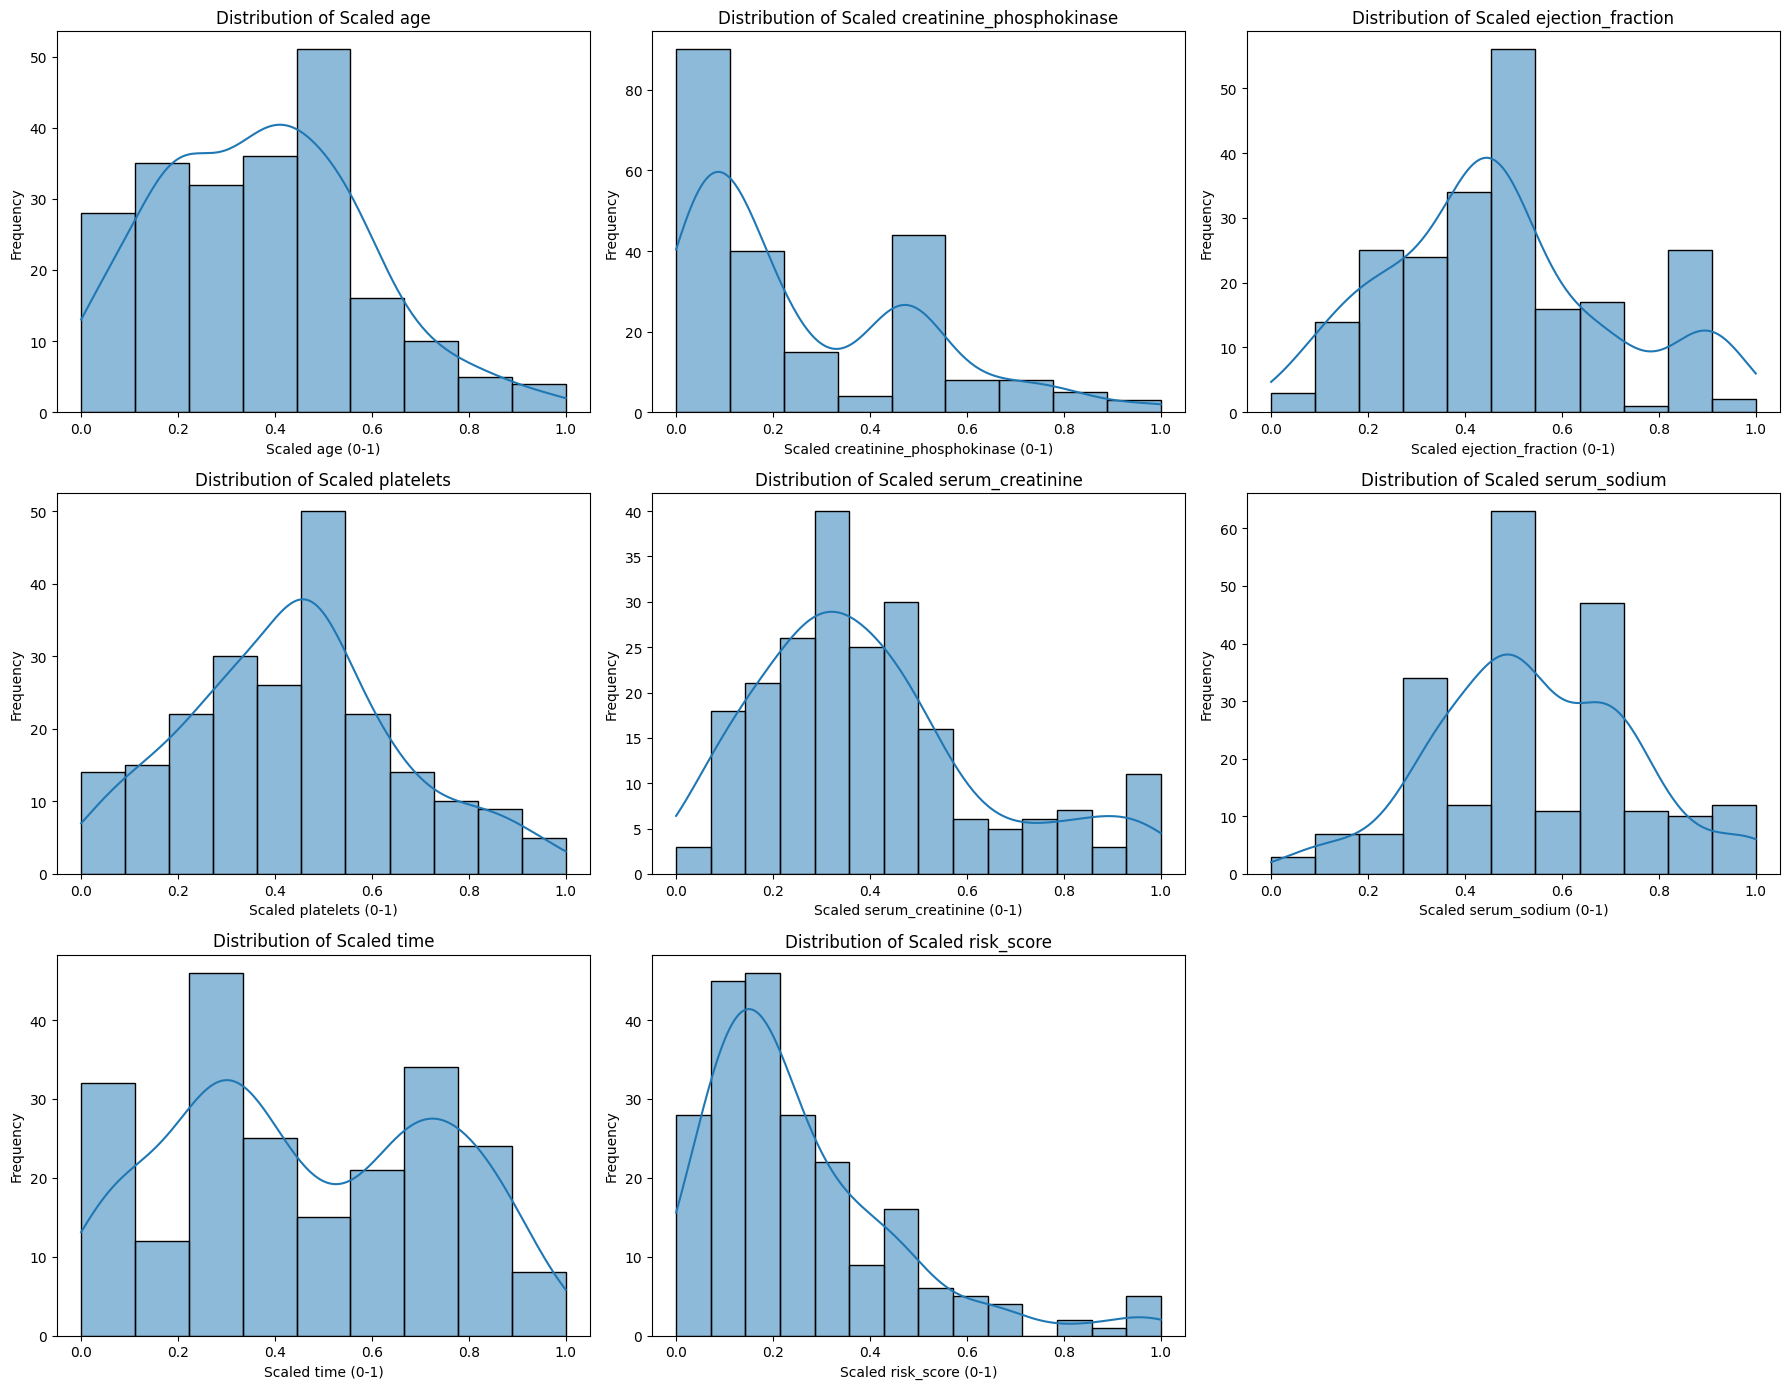


### Missing Values Check After All Cleaning and Preprocessing ###
No missing values found in the DataFrame after all cleaning and preprocessing steps.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot histograms for cleaned and scaled numerical features
print("### Histograms of Cleaned and Scaled Numerical Features ###")

# The list of numerical features that were scaled
numerical_features_scaled = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time',
    'risk_score' # The engineered and scaled risk_score
]

plt.figure(figsize=(18, 14))
for i, feature in enumerate(numerical_features_scaled, 1):
    plt.subplot(3, 3, i) # Adjust grid size as needed
    sns.histplot(df_heart_failure[feature], kde=True)
    plt.title(f'Distribution of Scaled {feature}')
    plt.xlabel(f'Scaled {feature} (0-1)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 2. Check for Missing Values
print("\n### Missing Values Check After All Cleaning and Preprocessing ###")
missing_values_after_cleaning = df_heart_failure.isnull().sum()

if missing_values_after_cleaning.sum() == 0:
    print("No missing values found in the DataFrame after all cleaning and preprocessing steps.")
else:
    print("Missing values still present in the following columns:")
    display(missing_values_after_cleaning[missing_values_after_cleaning > 0])